# None Set for Unknown Values

Top speed not reached within 0 m/s to 60 m/s (no +ax close to 0 crossing). Highlighting the highest speed in range instead.


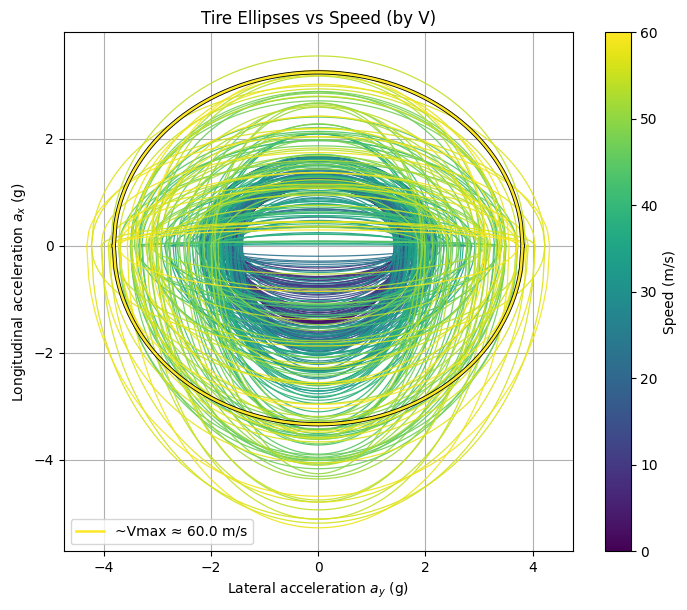

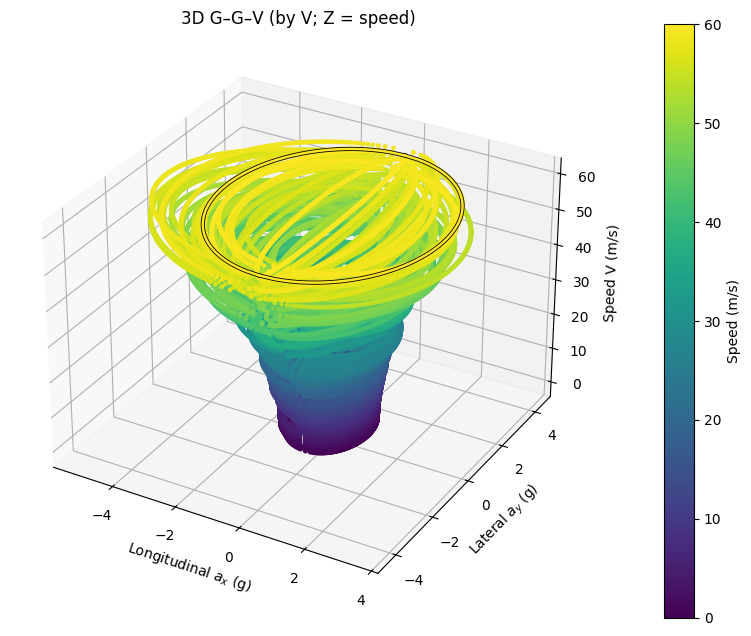

In [ ]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# Vehicle & aero inputs

M        = 310.0     # kg
G        = 9.81      # m/s^2
WHEELBASE= 1.550     # m // distance between front wheel center and back wheel center
TRACK    = 1.230     # m
H_CG     = 0.280     # m // 
FRONT_STATIC_FRAC = 0.53  # front axle fraction


# Downforce constants to calculate:
RHO = 1.225   # kg/m^3
CL  = -3.0    
A   = 1.0     # m^2
AERO_FRONT_BALANCE = 0.50  # the fraction of aero load on the front axle

# Power & drag cap
P_WN   = None       # W, wheel power available
ETA_DR = None       # drivetrain efficiency??
CDA    = None       # m^2, aerodynamic drag area

# Driveline assumption
DRIVEN_AXLE = "rear"

# Plot style
CMAP_NAME = 'viridis' #colormap for speed



# Lateral (Fy) coefficents using the tire data anlysis we had:

def B_lat(Fz): return -0.3488 - 0.0003*Fz - 1.3e-7*(Fz**2)
def C_lat(Fz): return 0.55092222 - 0.00244369*Fz - 1.0e-6*(Fz**2)
def D_lat(Fz): return 338.399 - 1.97694*Fz
def E_lat(Fz): return 0.35539 + 31.2449*np.exp(0.0164059*Fz)
def F_lat(Fz): return -0.0233809 - 1.77392e-4*Fz - 1.21226e-7*(Fz**2)

#function for calculating lateral F for slip angles and Fz from the pacejka equation and the coefficients

def Fy_pacejka(alpha, Fz):
    B, C, D, E, Svy = B_lat(Fz), C_lat(Fz), D_lat(Fz), E_lat(Fz), F_lat(Fz)
    return D*np.sin(C*np.arctan(B*alpha - E*(B*alpha - np.arctan(B*alpha)))) + Svy

# Longitudinal (Fx): don't use this function until we verify Fx later
# verify: Fz in kN, F(Fz) small angle in sine not offset, check shapes for a couple loads, 
# check magnitudes (mux = max|Fx|/Fz around 1-2 ish depending on the load/aero, at k = 0, 
# Fx should be very close to 0, traction and braking should be close to similar/mirror (k+ and k-)
# until these are verified have it set as FALSE


use_Fx_pacejka = False     # set this to true to use the Fx model below
mu_x_over_mu_y = 1.00      # if we have Fx off, lets just assume longitudinal grip = lateral grip 


def B_long(Fz): return -17.3662 - 9.50547*np.exp(0.00226287*Fz)
def C_long(Fz): return -0.00127868 + 1.35334e-5*Fz + 4.86905e-9*(Fz**2)
def D_long(Fz): return 43690.6 - 173.535*Fz - 0.0708504*(Fz**2)
def E_long(Fz): return -1.42217 + 0.0015213*Fz
def F_long(Fz): return 1.76214e-4 - 2.74311e-7*Fz

def Fx_pacejka(kappa, Fz):
    B, C, D, E, phi = B_long(Fz), C_long(Fz), D_long(Fz), E_long(Fz), F_long(Fz) 
    return D * np.sin(C*np.arctan(B*kappa - E*(B*kappa - np.arctan(B*kappa))) + phi)


# Pure of lateral and longitudinal i found that peak lateral forces usuallyy get around alpha = 5-15 so 25 is a conservative window i think???
#this is pure cornering 
def peak_lateral(Fz, alpha_max_deg=25.0):
    
    # used 1801 (odd so it includes 0) and gets closer peak estimate because it is denser
    
    alphas = np.deg2rad(np.linspace(-alpha_max_deg, alpha_max_deg, 1801))
    Fy_vals = Fy_pacejka(alphas, Fz)
    Fy_vals = np.nan_to_num(Fy_vals, nan=0.0, posinf=0.0, neginf=0.0) ## make sure NaN or inf results don't give result but just 0.0
    return float(np.max(np.abs(Fy_vals))) # out of all tests, max Fy
    

# for this one I found that peak longitudinal occurs around k = 0.08 to 0.15 ish so i think choosing 0.15 is a good conservative estimate??
# 
def peak_longitudinal(Fz, kappa_max=0.15):
    
    if use_Fx_pacejka:
        kappas = np.linspace(-kappa_max, kappa_max, 1801)
        Fx_vals = Fx_pacejka(kappas, Fz)
        Fx_vals = np.nan_to_num(Fx_vals, nan=0.0, posinf=0.0, neginf=0.0)
        return float(np.max(np.abs(Fx_vals)))
        
    # if Fx MF is off :
    
    mu_lat = peak_lateral(Fz)/max(Fz, 1.0)
    return float(mu_x_over_mu_y * mu_lat * Fz)

# Loads vs speed

W = M*G

def aero_downforce(V):  # positive magnitude
    
    return 0.5 * RHO * A * abs(CL) * V*V

## Need to get Cd*A here !!!

def aero_drag_force(V):
    
    if CDA is None:
        return 0.0
    return 0.5 * RHO * CDA * V*V

def per_wheel_loads(V, ax, ay, m=M, g=G, wheelbase=WHEELBASE, track=TRACK, h_cg=H_CG, front_static_frac=FRONT_STATIC_FRAC, 
                    rho=RHO, Cl=CL, A=A, 
                    aero_front_balance=AERO_FRONT_BALANCE,
                    k_longitudinal = None,     
                    phi_front=None  
                   ):

    ## k is the longitudinal transfer scale factor (pitch)
    # phi is the lateral tranfer (roll)
    
    """
    So for every wheels load we add these:
      - the regular static weight split i found from slack (0.53 front)
      - aero downforce split i just assumed is just divided by 2
      - longitudinal load transfer (pitch) from ax
      - lateral load transfer (roll) from ay
    this will return: Fz_fl, Fz_fr, Fz_rl, Fz_rr for the normal loads
    """

    # defaults if None provided
    if k_longitudinal is None:
        k_longitudinal = 1.0
    if phi_front is None:
        phi_front = 0.50
    
    # Basic axle loads just from the static + aero
    W  = m * g
    D  = 0.5 * rho * A * abs(Cl) * V * V  # total downforce magnitude (this is positive)
    Wf_base = W * front_static_frac       + D * aero_front_balance
    Wr_base = W * (1 - front_static_frac) + D * (1 - aero_front_balance)

    # Longitudinal transfer (pitch): +ax -> this is when the rear gains, and the front loses
    dF_long = k_longitudinal * (m * ax * h_cg / wheelbase)
    Wf = Wf_base - dF_long
    Wr = Wr_base + dF_long

    # start with equal left/right normal force on each axle
    Fz_fl = Fz_fr = Wf * 0.5
    Fz_rl = Fz_rr = Wr * 0.5

    # Lateral transfer (roll): ay>0 -> outside side of car gains
    dF_lat_total = m * abs(ay) * h_cg / track
    dF_lat_f = phi_front * dF_lat_total
    dF_lat_r = (1 - phi_front) * dF_lat_total
    sign = 1.0 if ay > 0 else (-1.0 if ay < 0 else 0.0)

    Fz_fl -= sign * (dF_lat_f * 0.5); Fz_fr += sign * (dF_lat_f * 0.5)
    Fz_rl -= sign * (dF_lat_r * 0.5); Fz_rr += sign * (dF_lat_r * 0.5)

    # make sure we dont have to worry about div by 0, NaN/inf
    eps = 1e-3
    return max(Fz_fl, eps), max(Fz_fr, eps), max(Fz_rl, eps), max(Fz_rr, eps)




# Per-speed tire limits with power & drag cap


def per_speed_limits(V, k_longitudinal=None, phi_front=None):
    # Pure lateral limit (ax = 0) with roll transfer 
    ay = 0.0
    for _ in range(6):
        Fz_fl, Fz_fr, Fz_rl, Fz_rr = per_wheel_loads(V, ax=0.0, ay=ay, k_longitudinal=k_longitudinal, phi_front=phi_front)
        Fy_peaks = [peak_lateral(Fz_fl), peak_lateral(Fz_fr), peak_lateral(Fz_rl), peak_lateral(Fz_rr)]
        ay_new = sum(Fy_peaks) / M
        
        if abs(ay_new - ay) < 1e-3: #convergence
            break
            
        ay = ay_new
    ay_max = ay_new

    # Pure acceleration limit (ay = 0) with pitch transfer
    ax = 0.0
    for _ in range(6):
        Fz_fl, Fz_fr, Fz_rl, Fz_rr = per_wheel_loads(V, ax=ax, ay=0.0, k_longitudinal=k_longitudinal, phi_front=phi_front)
        if DRIVEN_AXLE == "rear":
            Fx_sum = peak_longitudinal(Fz_rl) + peak_longitudinal(Fz_rr)
        elif DRIVEN_AXLE == "front":
            Fx_sum = peak_longitudinal(Fz_fl) + peak_longitudinal(Fz_fr)
        else:
            Fx_sum = (peak_longitudinal(Fz_fl) + peak_longitudinal(Fz_fr) +
                      peak_longitudinal(Fz_rl) + peak_longitudinal(Fz_rr))
        ax_tire = Fx_sum / M # tire limited accel (traction limited given the normal modes)

        # Power + drag cap 
        Veff  = max(V, 1e-3)
        if (P_WN is None) or (ETA_DR is None) or (CDA is None):
            ax_pow = np.inf
        else:
            P_av  = ETA_DR * P_WN
            Fd    = aero_drag_force(V)
            ax_pow = max(0.0, (P_av - Fd*Veff) / (M * Veff)) #this is the power limited accel for a V if we could have infinite grip

        ax_new = min(ax_tire, ax_pow) #the min is needed because we these are 2 constraints, so the tire can't push harder than the power allows, or we cant have power pushing more than the tire allows!!
        if abs(ax_new - ax) < 1e-3: #convergence
            break
        ax = ax_new
    ax_pos_max = ax_new

    # Pure braking limit (ay = 0) with pitch transfer (dont need power cap because here it is just tire limited, we arent supplying any energy here)
    ax = 0.0
    for _ in range(6):
        Fz_fl, Fz_fr, Fz_rl, Fz_rr = per_wheel_loads(V, ax=ax, ay=0.0, k_longitudinal =k_longitudinal, phi_front=phi_front)
        Fx_sum_all = (peak_longitudinal(Fz_fl) + peak_longitudinal(Fz_fr) +
                      peak_longitudinal(Fz_rl) + peak_longitudinal(Fz_rr))
        ax_new = -(Fx_sum_all / M)  # negative = braking
        if abs(ax_new - ax) < 1e-3:
            break
        ax = ax_new
    ax_neg_max = -ax_new  # return positive magnitude

    return ax_pos_max, ax_neg_max, ay_max




#When ax = 0 or really near 0, this is our max/top speed! (pwheel ower equals drag power)
#when we call this, V_list is created with the min V and max V with small steps
def compute_vmax(V_list, ax_pos_list, thresh=1e-3):
    """
     If +ax never drops to <= thresh within V_list, returns (None, None, None).
     """
    ax = np.array(ax_pos_list) #make array of ax for ax from each V
    
    # find first index where +ax <= thresh
    
    below = np.where(ax <= thresh)[0]
    
    if len(below) == 0:
        return None, None, None  # no crossing in the scanned range
    i2 = int(below[0]) #first index where ax <= threshold
    if i2 == 0:
        return V_list[0], None, i2
    i1 = i2 - 1
    # linear interpolation between (V1, a1) and (V2, a2) to estimate an ax=0 crossing
    V1, V2 = V_list[i1], V_list[i2]
    a1, a2 = ax[i1], ax[i2]
    if a2 == a1:
        return V2, i1, i2
    V_top = V1 + (0.0 - a1) * (V2 - V1) / (a2 - a1)
    return V_top, i1, i2





# Build ellipses + GGV (0 m/s to 60 m/s)

def build_ellipses_and_ggv(V_min=0.0, V_max=60.0, nV=241, n_ellipse_pts=241):
    """
    Returns:
      ellipses_2d: list of (V, ax_neg[], ay[], ax_pos[]) in m/s^2
      ggv_points : array Nx3 of [V, ax, ay] in SI
      ax_pos_arr : +ax limit per V (for Vmax calculation)
    """
    V_list = np.linspace(V_min, V_max, nV)
    ellipses_2d = []
    ggv_rows = []
    ax_pos_arr = []

    for V in V_list:
        ax_pos_max, ax_neg_max, ay_max = per_speed_limits(V)  # uses your function
        if not np.isfinite([ax_pos_max, ax_neg_max, ay_max]).all() or ay_max <= 0:
            ax_pos_arr.append(np.nan)
            continue
        # store +ax for Vmax finding
        ax_pos_arr.append(ax_pos_max)

        # ellipse points at this speed
        ax_neg, ay, ax_pos = ellipse_points(ax_pos_max, ax_neg_max, ay_max, n=n_ellipse_pts)
        msk_p = np.isfinite(ax_pos) & np.isfinite(ay)
        msk_n = np.isfinite(ax_neg) & np.isfinite(ay)
        ellipses_2d.append((V, ax_neg[msk_n], ay[msk_n], ax_pos[msk_p]))

        # GGV cloud (both sides of ellipse)
        ggv_rows += [(V, ax, yy) for ax, yy in zip(ax_pos[msk_p], ay[msk_p])]
        ggv_rows += [(V, ax, yy) for ax, yy in zip(ax_neg[msk_n], ay[msk_n])]

    ggv_points = np.array(ggv_rows) if len(ggv_rows) else np.zeros((0,3))
    return V_list, ellipses_2d, ggv_points, np.array(ax_pos_arr, dtype=float)


# Plot 2D ellipses (highlight the Vmax)

def plot_ellipses_ombre(ellipses_2d, V_highlight=None, cmap_name='viridis', g=9.81):
    if not ellipses_2d:
        print("No valid ellipses to plot."); return
    speeds = np.array([e[0] for e in ellipses_2d])
    cmap   = plt.get_cmap(cmap_name)
    norm   = mpl.colors.Normalize(vmin=speeds.min(), vmax=speeds.max())

    fig, ax = plt.subplots(figsize=(7.2,6.2))

    # draw all ellipses 
    for V, ax_neg, ay, ax_pos in ellipses_2d:
        c = cmap(norm(V))
        ax.plot(ay/g, ax_pos/g, color=c, linewidth=0.9, alpha=0.9)
        ax.plot(ay/g, ax_neg/g, color=c, linewidth=0.9, alpha=0.9)

    # highlight V_highlight 
    if V_highlight is not None:
        # find nearest ellipse to V_highlight
        idx = int(np.argmin(np.abs(speeds - V_highlight)))
        Vh, ax_neg, ay, ax_pos = ellipses_2d[idx]
        ch = cmap(norm(Vh))
        # outline 
        ax.plot(ay/g, ax_pos/g, color='k', linewidth=3.0, zorder=5)
        ax.plot(ay/g, ax_neg/g, color='k', linewidth=3.0, zorder=5)
        ax.plot(ay/g, ax_pos/g, color=ch, linewidth=1.8, zorder=6, label=f"~Vmax ≈ {V_highlight:.1f} m/s")
        ax.plot(ay/g, ax_neg/g, color=ch, linewidth=1.8, zorder=6)

    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label('Speed (m/s)')

    ax.set_xlabel('Lateral acceleration $a_y$ (g)')
    ax.set_ylabel('Longitudinal acceleration $a_x$ (g)')
    ax.set_title('Tire Ellipses vs Speed (by V)')
    if V_highlight is not None:
        ax.legend(loc='lower left', frameon=True)
    ax.grid(True)
    fig.tight_layout()
    plt.show()


# Plot 3D GGV (speed on Z-axis), highlight Vmax ellipse as a 3D ring


def plot_ggv_3d(ggv_points, ellipses_2d, V_highlight=None, cmap_name='viridis', g=9.81):
    if ggv_points.size == 0:
        print("No GGV points to plot."); return
    V  = ggv_points[:,0]
    axg= ggv_points[:,1]/g
    ayg= ggv_points[:,2]/g

    cmap = plt.get_cmap(cmap_name)
    norm = mpl.colors.Normalize(vmin=V.min(), vmax=V.max())

    fig = plt.figure(figsize=(8,6.4))
    ax3d = fig.add_subplot(111, projection='3d')

    # =scatter with Speed on Z axis (colored by V)
    sc = ax3d.scatter(axg, ayg, V, c=V, cmap=cmap, norm=norm, s=6, depthshade=False)

    # overlay Vmax ellipse as a 3D line at Z = V_highlight
    if (V_highlight is not None) and len(ellipses_2d):
        speeds = np.array([e[0] for e in ellipses_2d])
        idx = int(np.argmin(np.abs(speeds - V_highlight)))
        Vh, ax_neg, ay, ax_pos = ellipses_2d[idx]
        ch = cmap(norm(Vh))
        # Outline (black) at constant Z = Vh
        ax3d.plot(ax_pos/g, ay/g, np.full_like(ax_pos, Vh), color='k', linewidth=3.0, zorder=5)
        ax3d.plot(ax_neg/g, ay/g, np.full_like(ax_neg, Vh), color='k', linewidth=3.0, zorder=5)
        # Colored on top
        ax3d.plot(ax_pos/g, ay/g, np.full_like(ax_pos, Vh), color=ch, linewidth=1.8, zorder=6)
        ax3d.plot(ax_neg/g, ay/g, np.full_like(ax_neg, Vh), color=ch, linewidth=1.8, zorder=6)

    trace_x = []
    trace_y = []
    trace_z = []
    
    # Iterate through each ellipse and its corresponding Vmax
    for ellipse, vmax in zip(ellipses, vmax_list):
        # Extract ellipse parameters (assuming ellipse is defined by center, width, height, angle)
        # or as a set of points. If points:
        theta = np.linspace(0, 2 * np.pi, 100)
        
        # Assuming ellipse is a dictionary or object with a, b (semi-axes)
        # If ellipse is a pre-calculated contour:
        x_points = ellipse['x'] 
        y_points = ellipse['y']
        
        # Map the Vmax to the Z-axis for this specific slice
        z_points = np.full_like(x_points, vmax)

        # Plot the slice
        ax.plot(x_points, y_points, z_points, alpha=0.5)

        # To create a continuous trace through the "peak" or a specific trajectory:
        # Here we take the point at index 0 of each ellipse to form a longitudinal trace
        trace_x.append(x_points[0])
        trace_y.append(y_points[0])
        trace_z.append(vmax)

        
    ax3d.set_xlabel('Longitudinal $a_x$ (g)')
    ax3d.set_ylabel('Lateral $a_y$ (g)')
    ax3d.set_zlabel('Speed V (m/s)') 
    ax3d.set_title('3D G–G–V (by V; Z = speed)')

    cbar = plt.colorbar(sc, ax=ax3d, pad=0.10)
    cbar.set_label('Speed (m/s)')

    fig.tight_layout()
    plt.show()


#helper used above
def ellipse_points(ax_pos_max, ax_neg_max, ay_max, n=241):
    ay = np.linspace(-max(ay_max, 1e-12), max(ay_max, 1e-12), n)
    ax_pos =  ax_pos_max * np.sqrt(np.maximum(0.0, 1.0 - (ay/ay_max)**2))
    ax_neg = -ax_neg_max * np.sqrt(np.maximum(0.0, 1.0 - (ay/ay_max)**2))
    return ax_neg, ay, ax_pos


# RUN everything:

CMAP_NAME = 'viridis'  

V_list, ellipses_2d, ggv_points, ax_pos_arr = build_ellipses_and_ggv(V_min=0.0, V_max=60.0, nV=241, n_ellipse_pts=241)

# compute Vmax from +ax(V) curve
V_max_est, i1, i2 = compute_vmax(V_list, ax_pos_arr, thresh=1e-3)

# choose which ellipse to bold/outline --> this would be the top speed
V_highlight = V_max_est if V_max_est is not None else (V_list[-1] if len(V_list) else None)

# helpful print about top speed
if V_max_est is None:
    print("Top speed not reached within 0 m/s to 60 m/s (no +ax close to 0 crossing). Highlighting the highest speed in range instead.")
else:
    print(f"Estimated top speed (where +ax→0): V ≈ {V_max_est:.2f} m/s")

# Draw plots!!
plot_ellipses_ombre(ellipses_2d, V_highlight=V_highlight, cmap_name=CMAP_NAME, g=G)
plot_ggv_3d(ggv_points, ellipses_2d, V_highlight=V_highlight, cmap_name=CMAP_NAME, g=G)

# Tester Values for (P, Cd*A, phi, K_longitudinal)

Estimated top speed (where +ax→0): V ≈ 41.25 m/s


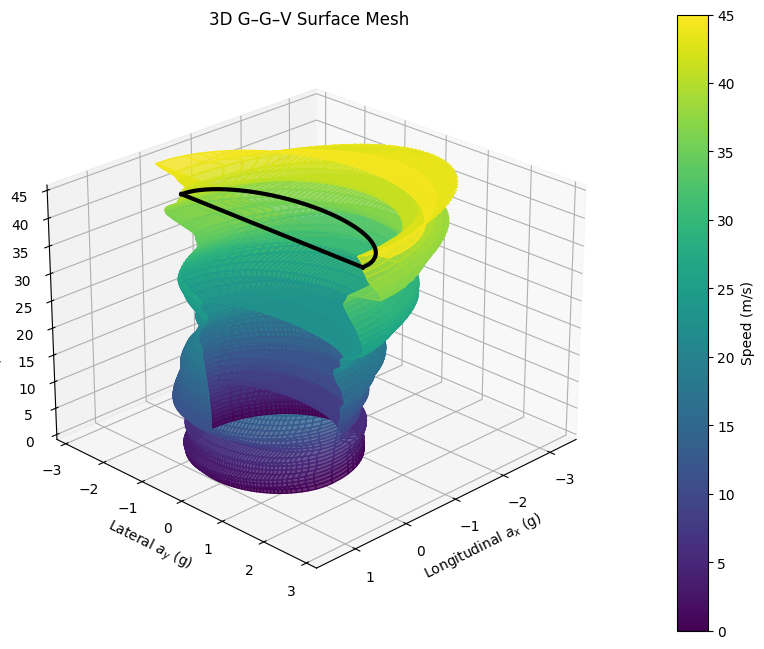

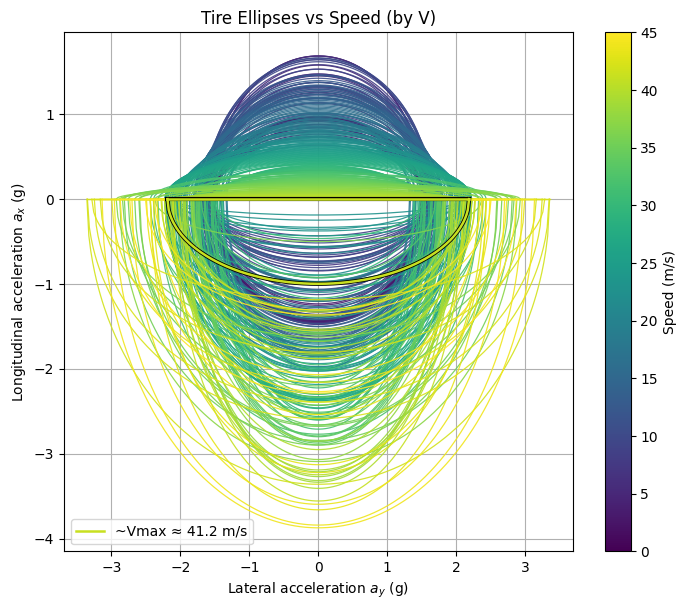

C:\Users\Kynam Lenghiem\AppData\Local\Temp\ipykernel_23444\3978326869.py:440: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


In [ ]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import minimize_scalar

# Vehicle & aero inputs

M        = 307.0     # kg
G        = 9.81      # m/s^2
WHEELBASE= 1.550     # m
TRACK    = 1.208     # m
H_CG     = 0.280     # m
FRONT_STATIC_FRAC = 0.53  # front axle fraction


# Downforce constants to calculate:
RHO = 1.225   # kg/m^3 
CL  = -3.0    
A   = 1.0     # m^2
AERO_FRONT_BALANCE = 0.50  # the fraction of aero load on the front axle

# Power & drag cap
P_WN   = 60000.0       # W, wheel power available
ETA_DR = 0.92       # drivetrain efficiency??
CDA    = 1.30       # m^2, aerodynamic drag area

# LLTD parameters
PHI_FRONT = 0.50  # fraction of lateral load transfer on front axle (rest is rear)
K_LONGITUDINAL = 1.0  # longitudinal load transfer scale factor (1.0 = full transfer, 0.0 = no transfer)


# Driveline assumption
DRIVEN_AXLE = "rear"

PER_WHEEL_SPEED_ITERATIONS = 6  # how many iterations to do to converge on the per-wheel loads for each speed (for the transfer effects)

# Longitudinal (Fx): don't use this function until we verify Fx later
# verify: Fz in kN, F(Fz) small angle in sine not offset, check shapes for a couple loads, 
# check magnitudes (mux = max|Fx|/Fz around 1-2 ish depending on the load/aero, at k = 0, 
# Fx should be very close to 0, traction and braking should be close to similar/mirror (k+ and k-)
# until these are verified have it set as FALSE
use_Fx_pacejka = False     # set this to true to use the Fx model below
mu_x_over_mu_y = 1.00      # if we have Fx off, lets just assume longitudinal grip = lateral grip 

# Lateral (Fy) coefficents using the tire data anlysis we had:
def B_lat(Fz): return -0.3488 - (0.0003*Fz) - (1.3e-7 * (Fz**2))
def C_lat(Fz): return 0.55092222 - (0.00244369*Fz) - (1.0e-6 * (Fz**2))
def D_lat(Fz): return 338.399 - (1.97694 * Fz)
def E_lat(Fz): return 0.35539 + (31.2449 * np.exp(0.0164059*Fz))
def F_lat(Fz): return -0.0233809 - (1.77392e-4*Fz) - (1.21226e-7 * (Fz**2))

#function for calculating lateral F for slip angles and Fz from the pacejka equation and the coefficients
def Fy_pacejka(alpha, Fz):
    B, C, D, E, Svy = B_lat(Fz), C_lat(Fz), D_lat(Fz), E_lat(Fz), F_lat(Fz)
    return D*np.sin(C*np.arctan(B*alpha - E*(B*alpha - np.arctan(B*alpha)))) + Svy

def B_long(Fz): return (-17.3662 - (9.50547 * np.exp(0.00226287 * Fz)))
def C_long(Fz): return (-0.00127868 + (1.35334e-5 * Fz) + (4.86905e-9 * (Fz**2)))
def D_long(Fz): return (43690.6 - (173.535 * Fz) - (0.0708504 * (Fz**2)))
def E_long(Fz): return (-1.42217 + (0.0015213 * Fz))
def F_long(Fz): return (1.76214e-4 - (2.74311e-7 * Fz))

def Fx_pacejka(kappa, Fz):
    B, C, D, E, phi = B_long(Fz), C_long(Fz), D_long(Fz), E_long(Fz), F_long(Fz) 
    return D * np.sin(C*np.arctan(B*kappa - E*(B*kappa - np.arctan(B*kappa))) + phi)

# Pure of lateral and longitudinal i found that peak lateral forces usuallyy get around alpha = 5-15 so 25 is a conservative window i think???
#this is pure cornering 
def peak_lateral(Fz, alpha_max_deg=25.0):
    
    # used 1801 (odd so it includes 0) and gets closer peak estimate because it is denser
    alphas = np.deg2rad(np.linspace(-alpha_max_deg, alpha_max_deg, 1801))
    Fy_vals = Fy_pacejka(alphas, Fz)
    Fy_vals = np.nan_to_num(Fy_vals, nan=0.0, posinf=0.0, neginf=0.0) ## make sure NaN or inf results don't give result but just 0.0
    return float(np.max(np.abs(Fy_vals))) # out of all tests, max Fy
    

# for this one I found that peak longitudinal occurs around k = 0.08 to 0.15 ish so i think choosing 0.15 is a good conservative estimate??
# 
def peak_longitudinal(Fz, kappa_max=0.15):
    
    if use_Fx_pacejka:
        kappas = np.linspace(-kappa_max, kappa_max, 1801)
        Fx_vals = Fx_pacejka(kappas, Fz)
        Fx_vals = np.nan_to_num(Fx_vals, nan=0.0, posinf=0.0, neginf=0.0)
        return float(np.max(np.abs(Fx_vals)))
        
    # if Fx MF is off :
    
    mu_lat = peak_lateral(Fz)/max(Fz, 1.0)
    return float(mu_x_over_mu_y * mu_lat * Fz)

# Loads vs speed
W = M*G

def aero_downforce(V):  # positive magnitude
    return 0.5 * RHO * A * abs(CL) * V*V


## Need to get Cd*A here !!!
def aero_drag_force(V):
    if CDA is None:
        return 0.0
    return 0.5 * RHO * CDA * V*V


def per_wheel_loads(V, ax, ay, m=M, g=G, wheelbase=WHEELBASE, track=TRACK, h_cg=H_CG, front_static_frac=FRONT_STATIC_FRAC, 
                    rho=RHO, Cl=CL, A=A, 
                    aero_front_balance=AERO_FRONT_BALANCE,
                    k_longitudinal = K_LONGITUDINAL,     
                    phi_front=PHI_FRONT  
                   ):
    ## k is the longitudinal transfer scale factor (pitch)
    # phi is the lateral tranfer (roll)
    
    """
    So for every wheels load we add these:
      - the regular static weight split i found from slack (0.53 front)
      - aero downforce split i just assumed is just divided by 2
      - longitudinal load transfer (pitch) from ax
      - lateral load transfer (roll) from ay
    this will return: Fz_fl, Fz_fr, Fz_rl, Fz_rr for the normal loads
    """

    # defaults if None provided
    if k_longitudinal is None:
        k_longitudinal = 1.0
    if phi_front is None:
        phi_front = 0.60
    
    # Basic axle loads just from the static + aero
    W  = m * g
    D  = 0.5 * rho * A * abs(Cl) * V * V  # total downforce magnitude (this is positive)
    Wf_base = W * front_static_frac       + D * aero_front_balance
    Wr_base = W * (1 - front_static_frac) + D * (1 - aero_front_balance)

    # Longitudinal transfer (pitch): +ax -> this is when the rear gains, and the front loses
    dF_long = k_longitudinal * (m * ax * h_cg / wheelbase)
    Wf = Wf_base - dF_long
    Wr = Wr_base + dF_long

    # start with equal left/right normal force on each axle
    Fz_fl = Fz_fr = Wf * 0.5
    Fz_rl = Fz_rr = Wr * 0.5

    # Lateral transfer (roll): ay>0 -> outside side of car gains
    dF_lat_total = m * abs(ay) * h_cg / track
    dF_lat_f = phi_front * dF_lat_total
    dF_lat_r = (1 - phi_front) * dF_lat_total
    sign = 1.0 if ay > 0 else (-1.0 if ay < 0 else 0.0)

    Fz_fl -= sign * (dF_lat_f * 0.5); Fz_fr += sign * (dF_lat_f * 0.5)
    Fz_rl -= sign * (dF_lat_r * 0.5); Fz_rr += sign * (dF_lat_r * 0.5)

    # make sure we dont have to worry about div by 0, NaN/inf
    eps = 1e-3
    return max(Fz_fl, eps), max(Fz_fr, eps), max(Fz_rl, eps), max(Fz_rr, eps)




# Per-speed tire limits with power & drag cap
def per_speed_limits(V, k_longitudinal=2, phi_front=PHI_FRONT):
    # Pure lateral limit (ax = 0) with roll transfer 
    ay = 0.0
    alpha = 1.0 # Damping factor for the iterative convergence of ay, helps prevent oscillations/divergence NOT TESTed...FOR NOW AT ZERO TO CANCEL FUNCTION 
    for _ in range(PER_WHEEL_SPEED_ITERATIONS):
        Fz_fl, Fz_fr, Fz_rl, Fz_rr = per_wheel_loads(V, ax=0.0, ay=ay, k_longitudinal=k_longitudinal, phi_front=phi_front)
        Fy_peaks = [peak_lateral(Fz_fl), peak_lateral(Fz_fr), peak_lateral(Fz_rl), peak_lateral(Fz_rr)]
        ay_target = sum(Fy_peaks) / M
        
        ay_new = (1 - alpha) * ay + alpha * ay_target 
        
        if abs(ay_new - ay) < 1e-3: 
            ay = ay_new
            break
            
        ay = ay_new
    ay_max = ay

    # Pure acceleration limit (ay = 0) with pitch transfer
    ax = 0.0
    for _ in range(PER_WHEEL_SPEED_ITERATIONS):
        Fz_fl, Fz_fr, Fz_rl, Fz_rr = per_wheel_loads(V, ax=ax, ay=0.0, k_longitudinal=k_longitudinal, phi_front=phi_front)
        if DRIVEN_AXLE == "rear":
            Fx_sum = peak_longitudinal(Fz_rl) + peak_longitudinal(Fz_rr)
        elif DRIVEN_AXLE == "front":
            Fx_sum = peak_longitudinal(Fz_fl) + peak_longitudinal(Fz_fr)
        else:
            Fx_sum = (peak_longitudinal(Fz_fl) + peak_longitudinal(Fz_fr) +
                      peak_longitudinal(Fz_rl) + peak_longitudinal(Fz_rr))
        ax_tire = Fx_sum / M # tire limited accel (traction limited given the normal modes)

        # Power + drag cap 
        Veff  = max(V, 1e-3)
        if (P_WN is None) or (ETA_DR is None) or (CDA is None):
            ax_pow = np.inf
        else:
            P_av  = ETA_DR * P_WN
            Fd    = aero_drag_force(V)
            ax_pow = max(0.0, (P_av - Fd*Veff) / (M * Veff)) #this is the power limited accel for a V if we could have infinite grip

        # Damping to prevent oscillations/divergence in the iterative solution for ax
        #the min is needed because we these are 2 constraints, so the tire can't push harder than the power allows, or we cant have power pushing more than the tire allows!!
        ax_target = min(ax_tire, ax_pow)
        ax_new = (1 - alpha) * ax + alpha * ax_target
        
        if abs(ax_new - ax) < 1e-3: 
            ax = ax_new
            break

        ax = ax_new
    ax_pos_max = ax_new

    # Pure braking limit (ay = 0) with pitch transfer (dont need power cap because here it is just tire limited, we arent supplying any energy here)
    ax = 0.0
    for _ in range(PER_WHEEL_SPEED_ITERATIONS):
        Fz_fl, Fz_fr, Fz_rl, Fz_rr = per_wheel_loads(V, ax=ax, ay=0.0, k_longitudinal =K_LONGITUDINAL, phi_front=PHI_FRONT)
        Fx_sum_all = (peak_longitudinal(Fz_fl) + peak_longitudinal(Fz_fr) +
                      peak_longitudinal(Fz_rl) + peak_longitudinal(Fz_rr))
        ax_new = -(Fx_sum_all / M)  # negative = braking
        if abs(ax_new - ax) < 1e-3:
            break
        ax = ax_new
    ax_neg_max = -ax_new  # return positive magnitude

    return ax_pos_max, ax_neg_max, ay_max




#When ax = 0 or really near 0, this is our max/top speed! (pwheel ower equals drag power)
#when we call this, V_list is created with the min V and max V with small steps
def compute_vmax(V_list, ax_pos_list, thresh=1e-3):
    """
     If +ax never drops to <= thresh within V_list, returns (None, None, None).
     """
    ax = np.array(ax_pos_list) #make array of ax for ax from each V
    
    # find first index where +ax <= thresh
    below = np.where(ax <= thresh)[0]
    
    if len(below) == 0:
        return None, None, None  # no crossing in the scanned range
    i2 = int(below[0]) #first index where ax <= threshold
    if i2 == 0:
        return V_list[0], None, i2
    i1 = i2 - 1
    # linear interpolation between (V1, a1) and (V2, a2) to estimate an ax=0 crossing
    V1, V2 = V_list[i1], V_list[i2]
    a1, a2 = ax[i1], ax[i2]
    if a2 == a1:
        return V2, i1, i2
    V_top = V1 + (0.0 - a1) * (V2 - V1) / (a2 - a1)
    return V_top, i1, i2



# Build ellipses + GGV (0 m/s to 60 m/s)
def build_ellipses_and_ggv(V_min=0.0, V_max=60.0, nV=241, n_ellipse_pts=241):
    """
    Returns:
      ellipses_2d: list of (V, ax_neg[], ay[], ax_pos[]) in m/s^2
      ggv_points : array Nx3 of [V, ax, ay] in SI
      ax_pos_arr : +ax limit per V (for Vmax calculation)
    """
    V_list = np.linspace(V_min, V_max, nV)
    ellipses_2d = []
    ggv_rows = []
    ax_pos_arr = []

    for V in V_list:
        ax_pos_max, ax_neg_max, ay_max = per_speed_limits(V)  # uses your function
        if not np.isfinite([ax_pos_max, ax_neg_max, ay_max]).all() or ay_max <= 0:
            ax_pos_arr.append(np.nan)
            continue
        # store +ax for Vmax finding
        ax_pos_arr.append(ax_pos_max)

        # ellipse points at this speed
        ax_neg, ay, ax_pos = ellipse_points(ax_pos_max, ax_neg_max, ay_max, n=n_ellipse_pts)
        msk_p = np.isfinite(ax_pos) & np.isfinite(ay)
        msk_n = np.isfinite(ax_neg) & np.isfinite(ay)
        ellipses_2d.append((V, ax_neg[msk_n], ay[msk_n], ax_pos[msk_p]))

        # GGV cloud (both sides of ellipse)
        ggv_rows += [(V, ax, yy) for ax, yy in zip(ax_pos[msk_p], ay[msk_p])]
        ggv_rows += [(V, ax, yy) for ax, yy in zip(ax_neg[msk_n], ay[msk_n])]

    ggv_points = np.array(ggv_rows) if len(ggv_rows) else np.zeros((0,3))
    return V_list, ellipses_2d, ggv_points, np.array(ax_pos_arr, dtype=float)


# Plot 2D ellipses (highlight the Vmax)
def plot_ellipses_ombre(ellipses_2d, V_highlight=None, cmap_name='viridis', g=9.81):
    if not ellipses_2d:
        print("No valid ellipses to plot."); return
    speeds = np.array([e[0] for e in ellipses_2d])
    cmap   = plt.get_cmap(cmap_name)
    norm   = mpl.colors.Normalize(vmin=speeds.min(), vmax=speeds.max())

    fig, ax = plt.subplots(figsize=(7.2,6.2))

    # draw all ellipses 
    for V, ax_neg, ay, ax_pos in ellipses_2d:
        c = cmap(norm(V))
        ax.plot(ay/g, ax_pos/g, color=c, linewidth=0.9, alpha=0.9)
        ax.plot(ay/g, ax_neg/g, color=c, linewidth=0.9, alpha=0.9)

    # highlight V_highlight 
    if V_highlight is not None:
        # find nearest ellipse to V_highlight
        idx = int(np.argmin(np.abs(speeds - V_highlight)))
        Vh, ax_neg, ay, ax_pos = ellipses_2d[idx]
        ch = cmap(norm(Vh))
        # outline 
        ax.plot(ay/g, ax_pos/g, color='k', linewidth=3.0, zorder=5)
        ax.plot(ay/g, ax_neg/g, color='k', linewidth=3.0, zorder=5)
        ax.plot(ay/g, ax_pos/g, color=ch, linewidth=1.8, zorder=6, label=f"~Vmax ≈ {V_highlight:.1f} m/s")
        ax.plot(ay/g, ax_neg/g, color=ch, linewidth=1.8, zorder=6)

    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label('Speed (m/s)')

    ax.set_xlabel('Lateral acceleration $a_y$ (g)')
    ax.set_ylabel('Longitudinal acceleration $a_x$ (g)')
    ax.set_title('Tire Ellipses vs Speed (by V)')
    if V_highlight is not None:
        ax.legend(loc='lower left', frameon=True)
    ax.grid(True)
    fig.tight_layout()
    plt.show()


# Plot 3D GGV (speed on Z-axis), highlight Vmax ellipse as a 3D ring
def plot_ggv_3d(ggv_points, ellipses_2d, V_highlight=None, cmap_name='viridis', g=9.81):
    if ggv_points.size == 0:
        print("No GGV points to plot."); return
    V  = ggv_points[:,0]
    axg= ggv_points[:,1]/g
    ayg= ggv_points[:,2]/g

    cmap = plt.get_cmap(cmap_name)
    norm = mpl.colors.Normalize(vmin=V.min(), vmax=V.max())

    fig = plt.figure(figsize=(8,6.4))
    ax3d = fig.add_subplot(111, projection='3d')

    # =scatter with Speed on Z axis (colored by V)
    sc = ax3d.scatter(axg, ayg, V, c=V, cmap=cmap, norm=norm, s=6, depthshade=False)

    # overlay Vmax ellipse as a 3D line at Z = V_highlight
    if (V_highlight is not None) and len(ellipses_2d):
        speeds = np.array([e[0] for e in ellipses_2d])
        idx = int(np.argmin(np.abs(speeds - V_highlight)))
        Vh, ax_neg, ay, ax_pos = ellipses_2d[idx]
        ch = cmap(norm(Vh))
        # Outline (black) at constant Z = Vh
        ax3d.plot(ax_pos/g, ay/g, np.full_like(ax_pos, Vh), color='k', linewidth=3.0, zorder=5)
        ax3d.plot(ax_neg/g, ay/g, np.full_like(ax_neg, Vh), color='k', linewidth=3.0, zorder=5)
        # Colored on top
        ax3d.plot(ax_pos/g, ay/g, np.full_like(ax_pos, Vh), color=ch, linewidth=1.8, zorder=6)
        ax3d.plot(ax_neg/g, ay/g, np.full_like(ax_neg, Vh), color=ch, linewidth=1.8, zorder=6)

    # labeling and formatting
    ax3d.set_xlabel('Longitudinal $a_x$ (g)')
    ax3d.set_ylabel('Lateral $a_y$ (g)')
    ax3d.set_zlabel('Speed V (m/s)') 
    ax3d.set_title('3D G–G–V (by V; Z = speed)')

    cbar = plt.colorbar(sc, ax=ax3d, pad=0.10)
    cbar.set_label('Speed (m/s)')

    fig.tight_layout()
    plt.show()

def plot_ggv_3d_surface(ellipses_2d, V_highlight=None, cmap_name='viridis', g=G):
    # 0 check we have data to plot
    if not ellipses_2d:
        print("No GGV points to plot."); return
        
    # 1. Unpack the lists into 2D matrices (The Grid)
    # Shape of each will be (nV, n_ellipse_pts) -> (241, 241)
    V_grid = (np.array([[e[0]] * len(e[2]) for e in ellipses_2d]))
    ax_neg_grid = np.array([e[1] for e in ellipses_2d]) / g      
    ay_grid = np.array([e[2] for e in ellipses_2d]) / g          
    ax_pos_grid = np.array([e[3] for e in ellipses_2d]) / g  

    smooth_sigma = 2 
    ax_pos_grid = gaussian_filter1d(ax_pos_grid, sigma=smooth_sigma, axis=0)
    ax_neg_grid = gaussian_filter1d(ax_neg_grid, sigma=smooth_sigma, axis=0)
    ay_grid = gaussian_filter1d(ay_grid, sigma=smooth_sigma, axis=0)

    # Setup figure
    fig = plt.figure(figsize=(10, 8))
    ax3d = fig.add_subplot(111, projection='3d')

    cmap = plt.get_cmap(cmap_name)
    norm = mpl.colors.Normalize(vmin=V_grid.min(), vmax=V_grid.max())

    # 2. Plot the surfaces! 
    # Top half (+ax, Acceleration)
    surf1 = ax3d.plot_surface(ax_pos_grid, ay_grid, V_grid, 
                             facecolors=cmap(norm(V_grid)), 
                             rstride=4, cstride=4, antialiased=True, shade=False, alpha=0.8)
                      
    # Bottom half (-ax, Braking)
    surf2 = ax3d.plot_surface(ax_neg_grid, ay_grid, V_grid, 
                             facecolors=cmap(norm(V_grid)), 
                             rstride=4, cstride=4, antialiased=True, shade=False, alpha=0.8)

    # 3. Keep your V_highlight logic (The black ring)
    if (V_highlight is not None) and len(ellipses_2d):
        speeds = np.array([e[0] for e in ellipses_2d])
        idx = int(np.argmin(np.abs(speeds - V_highlight)))
        Vh, ax_neg, ay, ax_pos = ellipses_2d[idx]
        ch = cmap(norm(Vh))
        
        ax3d.plot(ax_pos/g, ay/g, np.full_like(ax_pos, Vh), color='k', linewidth=3.0, zorder=5)
        ax3d.plot(ax_neg/g, ay/g, np.full_like(ax_neg, Vh), color='k', linewidth=3.0, zorder=5)

    # Labels and formatting
    ax3d.set_xlabel('Longitudinal $a_x$ (g)')
    ax3d.set_ylabel('Lateral $a_y$ (g)')
    ax3d.set_zlabel('Speed V (m/s)') 
    ax3d.set_title('3D G–G–V Surface Mesh')

    # Colorbar needs a scalar mappable for surfaces
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    cbar = plt.colorbar(sm, ax=ax3d, pad=0.10)
    cbar.set_label('Speed (m/s)')

    # Set a nice viewing angle
    ax3d.view_init(elev=25, azim=45)

    # Enable interactive rotation
    plt.ion()
    fig.show()
    plt.ioff()


#helper used above
def ellipse_points(ax_pos_max, ax_neg_max, ay_max, n=241):
    ay = np.linspace(-max(ay_max, 1e-12), max(ay_max, 1e-12), n)
    ax_pos =  ax_pos_max * np.sqrt(np.maximum(0.0, 1.0 - (ay/ay_max)**2))
    ax_neg = -ax_neg_max * np.sqrt(np.maximum(0.0, 1.0 - (ay/ay_max)**2))
    return ax_neg, ay, ax_pos



# RUN everything:
CMAP_NAME = 'viridis'  

V_list, ellipses_2d, ggv_points, ax_pos_arr = build_ellipses_and_ggv(V_min=0.0, V_max=45.0, nV=241, n_ellipse_pts=241)

# compute Vmax from +ax(V) curve
V_max_est, i1, i2 = compute_vmax(V_list, ax_pos_arr, thresh=1e-3)

# choose which ellipse to bold/outline --> this would be the top speed
V_highlight = V_max_est if V_max_est is not None else (V_list[-1] if len(V_list) else None)

# helpful print about top speed
if V_max_est is None:
    print("Top speed not reached within 0 m/s to 60 m/s (no +ax close to 0 crossing). Highlighting the highest speed in range instead.")
else:
    print(f"Estimated top speed (where +ax→0): V ≈ {V_max_est:.2f} m/s")

# Draw plots!!
plot_ellipses_ombre(ellipses_2d, V_highlight=V_highlight, cmap_name=CMAP_NAME, g=G)
plot_ggv_3d_surface(ellipses_2d, V_highlight=V_highlight, cmap_name=CMAP_NAME, g=G)


# params as a function of % front lateral load transfer distribution


In [ ]:
max_velo = 12.0 #m/s